CLASS IMBALANCE QUANTIFICATION
Total transactions: 284,807
Legitimate transactions: 284,315 (99.83%)
Fraud transactions: 492 (0.1727%)
Imbalance ratio: 577.88:1


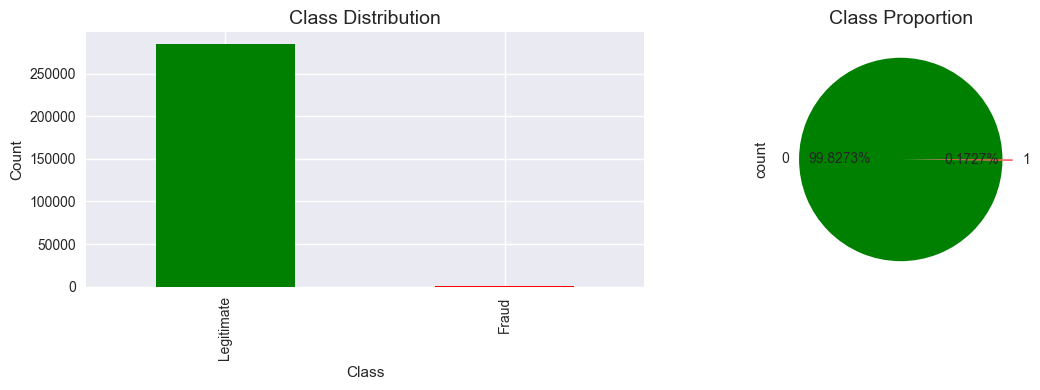


AMOUNT ANALYSIS BY CLASS
Legitimate - Mean: $88.29, Median: $22.00
Fraud - Mean: $122.21, Median: $9.25


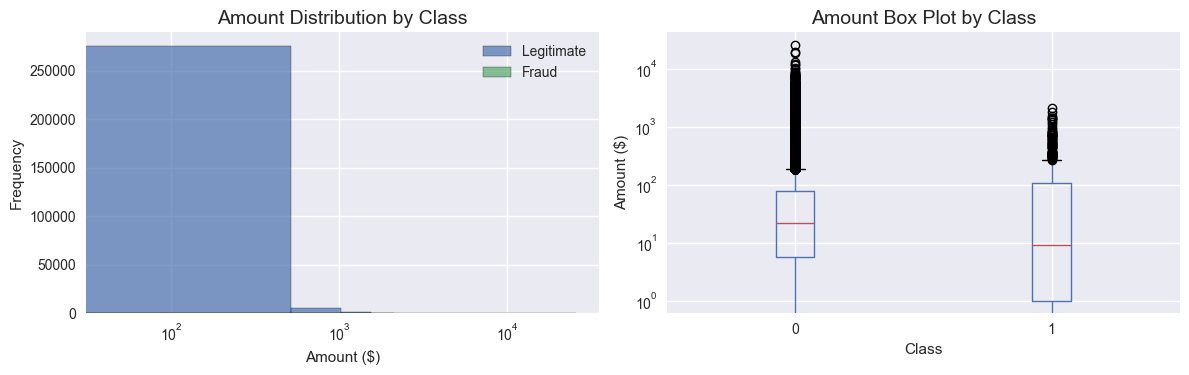


TIME ANALYSIS
Time range: 0.0 to 172792.0 seconds
Time span: 48.0 hours


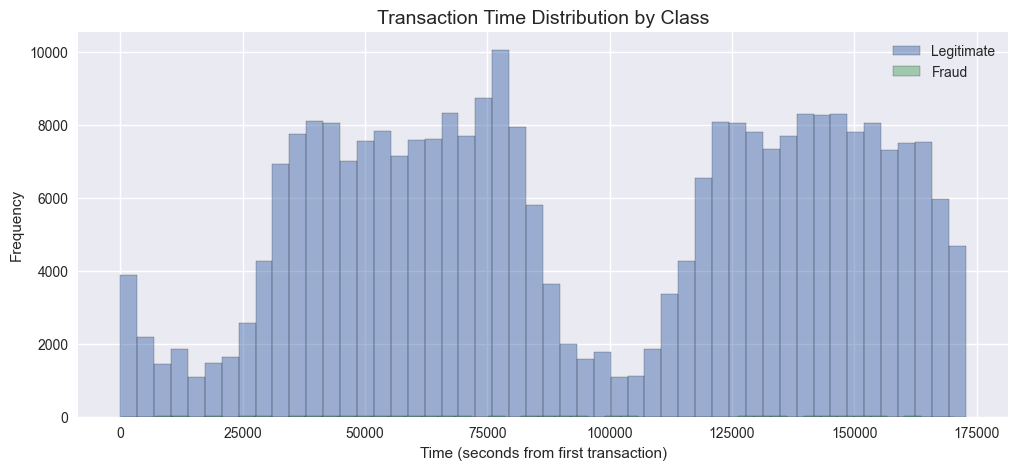

In [1]:
# Complete EDA notebook for credit card data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')

# Load data
df = pd.read_csv('../data/raw/creditcard.csv')

# ============================================
# 1. CLASS IMBALANCE QUANTIFICATION
# ============================================
print("="*50)
print("CLASS IMBALANCE QUANTIFICATION")
print("="*50)

fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_rate = fraud_count / len(df)

print(f"Total transactions: {len(df):,}")
print(f"Legitimate transactions: {legit_count:,} ({legit_count/len(df)*100:.2f}%)")
print(f"Fraud transactions: {fraud_count:,} ({fraud_count/len(df)*100:.4f}%)")
print(f"Imbalance ratio: {legit_count/fraud_count:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_xticklabels(['Legitimate', 'Fraud'])
axes[0].set_ylabel('Count')

df['Class'].value_counts().plot(kind='pie', autopct='%1.4f%%', ax=axes[1],
                                 colors=['green', 'red'], explode=[0, 0.1])
axes[1].set_title('Class Proportion', fontsize=14)

plt.tight_layout()
plt.savefig('../reports/credit_class_distribution.png', dpi=150)
plt.show()

# ============================================
# 2. AMOUNT ANALYSIS BY CLASS
# ============================================
print("\n" + "="*50)
print("AMOUNT ANALYSIS BY CLASS")
print("="*50)

legit_amounts = df[df['Class']==0]['Amount']
fraud_amounts = df[df['Class']==1]['Amount']

print(f"Legitimate - Mean: ${legit_amounts.mean():.2f}, Median: ${legit_amounts.median():.2f}")
print(f"Fraud - Mean: ${fraud_amounts.mean():.2f}, Median: ${fraud_amounts.median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
legit_amounts.hist(bins=50, ax=axes[0], alpha=0.7, label='Legitimate', edgecolor='black')
fraud_amounts.hist(bins=50, ax=axes[0], alpha=0.7, label='Fraud', edgecolor='black')
axes[0].set_title('Amount Distribution by Class', fontsize=14)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xscale('log')

df.boxplot(column='Amount', by='Class', ax=axes[1])
axes[1].set_title('Amount Box Plot by Class', fontsize=14)
axes[1].set_ylabel('Amount ($)')
axes[1].set_yscale('log')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../reports/credit_amount_by_class.png', dpi=150)
plt.show()

# ============================================
# 3. TIME ANALYSIS
# ============================================
print("\n" + "="*50)
print("TIME ANALYSIS")
print("="*50)
print(f"Time range: {df['Time'].min()} to {df['Time'].max()} seconds")
print(f"Time span: {df['Time'].max()/3600:.1f} hours")

fig, ax = plt.subplots(figsize=(12, 5))
df[df['Class']==0]['Time'].hist(bins=50, alpha=0.5, label='Legitimate', edgecolor='black')
df[df['Class']==1]['Time'].hist(bins=50, alpha=0.5, label='Fraud', edgecolor='black')
ax.set_title('Transaction Time Distribution by Class', fontsize=14)
ax.set_xlabel('Time (seconds from first transaction)')
ax.set_ylabel('Frequency')
ax.legend()
plt.savefig('../reports/credit_time_distribution.png', dpi=150)
plt.show()